Install packages

In [1]:
# =========================================================
# AGRODETECT AI
# PART 1 — INSTALLATION
# =========================================================

!pip install -q -U \
    langchain \
    langgraph \
    langchain-groq \
    "mcp[cli]" \
    pandas \
    numpy \
    scikit-learn \
    matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.6/139.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.8/247.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.6/69.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.0/350.0 kB 19.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is th

Imports

In [2]:
# =========================================================
# IMPORTS
# =========================================================

import os
import json
import warnings

import pandas as pd
import numpy as np

from IPython.display import display, Markdown

warnings.filterwarnings("ignore")

print("✅ AgroDetect AI libraries loaded")

✅ AgroDetect AI libraries loaded


Load Groq

In [3]:
# =========================================================
# GROQ API KEY
# =========================================================

from google.colab import userdata

GROQ_API_KEY = userdata.get("GROQ_API_KEY")

if not GROQ_API_KEY:
    raise ValueError(
        "❌ GROQ_API_KEY not found in Colab Secrets"
    )

os.environ["GROQ_API_KEY"] = GROQ_API_KEY

print("✅ Groq API key loaded")

✅ Groq API key loaded


Initialize Groq LLM

In [4]:
# =========================================================
# GROQ LLM
# =========================================================

from langchain_groq import ChatGroq

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

print("✅ Groq LLM initialized")

✅ Groq LLM initialized


Test Groq

In [5]:
# =========================================================
# TEST GROQ
# =========================================================

response = llm.invoke(
    "You are AgroDetect AI. "
    "Reply with exactly: AgroDetect AI is ready."
)

print(response.content)

AgroDetect AI is ready.


Test LangGraph

In [6]:
# =========================================================
# LANGGRAPH TEST
# =========================================================

from typing import TypedDict

from langgraph.graph import (
    StateGraph,
    START,
    END
)


class AgroState(TypedDict):
    message: str


def agro_test_agent(state: AgroState):

    response = llm.invoke(
        "Say: AgroDetect AI LangGraph workflow is ready."
    )

    return {
        "message": response.content
    }


builder = StateGraph(AgroState)

builder.add_node(
    "agro_test_agent",
    agro_test_agent
)

builder.add_edge(
    START,
    "agro_test_agent"
)

builder.add_edge(
    "agro_test_agent",
    END
)

agro_graph = builder.compile()

result = agro_graph.invoke({
    "message": ""
})

print(result["message"])

AgroDetect AI LangGraph workflow is ready.


Create MCP Server

In [7]:
# =========================================================
# MCP SERVER
# =========================================================

from mcp.server import MCPServer
from mcp import Client

mcp = MCPServer(
    "AgroDetect MCP Server"
)

print("✅ AgroDetect MCP Server created")

✅ AgroDetect MCP Server created


Create first MCP tool

In [8]:
# =========================================================
# MCP TOOL — SYSTEM STATUS
# =========================================================

@mcp.tool()
def agro_system_status() -> str:
    """
    Check whether AgroDetect AI MCP system is ready.
    """

    return json.dumps({
        "project": "AgroDetect AI",
        "status": "ready",
        "llm": "Groq",
        "framework": "LangChain + LangGraph",
        "protocol": "MCP",
        "domain": "Agricultural Intelligence"
    })

print("✅ MCP tool registered: agro_system_status")

✅ MCP tool registered: agro_system_status


Test MCP Client

In [9]:
# =========================================================
# MCP CLIENT TEST
# =========================================================

async with Client(mcp) as client:

    tools = await client.list_tools()

    print("====================================")
    print("AVAILABLE MCP TOOLS")
    print("====================================")

    for tool in tools.tools:
        print("•", tool.name)

    result = await client.call_tool(
        "agro_system_status",
        {}
    )

    print("\n====================================")
    print("MCP RESULT")
    print("====================================")

    # Show only clean tool output
    print(result.content[0].text)

AVAILABLE MCP TOOLS
• agro_system_status

MCP RESULT
{"project": "AgroDetect AI", "status": "ready", "llm": "Groq", "framework": "LangChain + LangGraph", "protocol": "MCP", "domain": "Agricultural Intelligence"}


                 AgroDetect AI
                       │
                       ↓
                  Groq LLM
                       │
                       ↓
                  LangChain
                       │
                       ↓
                  LangGraph
                       │
                       ↓
                  MCP Client
                       │
                       ↓
                  MCP Server
                       │
                       ↓
             agro_system_status()

Upload

In [10]:
from google.colab import files

uploaded = files.upload()

Saving agricultural.csv to agricultural.csv


Set the path

In [11]:
# =========================================================
# AGRICULTURAL DATASET
# =========================================================

CSV_PATH = "/content/agricultural.csv"

print("Dataset:", CSV_PATH)

Dataset: /content/agricultural.csv


Load and inspect

In [12]:
# =========================================================
# LOAD AGRICULTURAL DATA
# =========================================================

df = pd.read_csv(CSV_PATH)

print("✅ Agricultural dataset loaded")
print()
print("Rows    :", len(df))
print("Columns :", len(df.columns))

print("\nColumn names:")
for col in df.columns:
    print("•", col)

display(df.head())

✅ Agricultural dataset loaded

Rows    : 1200
Columns : 12

Column names:
• Region
• Crop
• Soil_Type
• Irrigation_Type
• Rainfall_mm
• Temperature_C
• Humidity_Percent
• Soil_Moisture_Percent
• Fertilizer_kg_per_hectare
• Irrigation_Hours
• Pest_Level
• Crop_Yield_Tons_per_Hectare


,Region,Crop,Soil_Type,Irrigation_Type,Rainfall_mm,Temperature_C,Humidity_Percent,Soil_Moisture_Percent,Fertilizer_kg_per_hectare,Irrigation_Hours,Pest_Level,Crop_Yield_Tons_per_Hectare
0,Maharashtra,Cotton,Red Soil,Rainfed,411.1,30.5,77.8,35.2,128.2,7.7,2.9,3.81
1,Punjab,Cotton,Loamy,Rainfed,800.4,30.4,67.8,55.3,78.5,5.2,4.8,5.43
2,Andhra Pradesh,Cotton,Sandy,Drip,693.4,28.1,51.1,37.7,85.8,7.2,6.8,4.54
3,Punjab,Sugarcane,Loamy,Rainfed,1103.4,28.7,65.1,49.4,102.4,3.1,2.0,6.55
4,Punjab,Sugarcane,Red Soil,Rainfed,911.5,28.9,91.2,56.5,106.6,9.7,2.3,6.35


Create MCP Dataset Summary Tool

In [13]:
# =========================================================
# MCP TOOL 1 → DATASET SUMMARY
# =========================================================

@mcp.tool()
def get_crop_dataset_summary() -> str:
    """Return basic information about the agricultural dataset."""

    data = pd.read_csv(CSV_PATH)

    result = {
        "Dataset": "agricultural.csv",
        "Total Records": int(len(data)),
        "Total Columns": int(len(data.columns)),
        "Columns": list(data.columns),
        "Missing Values": int(data.isna().sum().sum()),
        "Duplicate Rows": int(data.duplicated().sum())
    }

    return json.dumps(result, indent=2)

print("✅ MCP tool registered")

✅ MCP tool registered


Create MCP Crop Statistics Tool

In [14]:
# =========================================================
# MCP TOOL 2 → CROP STATISTICS
# =========================================================

@mcp.tool()
def get_crop_statistics() -> str:
    """Return numerical statistics from the agricultural dataset."""

    data = pd.read_csv(CSV_PATH)

    numeric_columns = data.select_dtypes(
        include=np.number
    ).columns

    statistics = {}

    for column in numeric_columns:

        statistics[column] = {
            "mean": round(float(data[column].mean()), 2),
            "minimum": round(float(data[column].min()), 2),
            "maximum": round(float(data[column].max()), 2)
        }

    return json.dumps(statistics, indent=2)

print("✅ MCP statistics tool registered")

✅ MCP statistics tool registered


Create MCP Missing-Value Tool

In [15]:
# =========================================================
# MCP TOOL 3 → DATA QUALITY
# =========================================================

@mcp.tool()
def get_missing_value_analysis() -> str:
    """Identify missing values in agricultural data."""

    data = pd.read_csv(CSV_PATH)

    missing = data.isna().sum()

    result = {
        column: int(count)
        for column, count in missing.items()
        if count > 0
    }

    return json.dumps(result, indent=2)

print("✅ MCP data-quality tool registered")

✅ MCP data-quality tool registered


Check MCP Tools

In [16]:
# =========================================================
# MCP TOOL DISCOVERY
# =========================================================

async with Client(mcp) as client:

    tools = await client.list_tools()

    print("====================================")
    print("AGRODETECT MCP TOOLS")
    print("====================================")

    for tool in tools.tools:
        print("•", tool.name)

AGRODETECT MCP TOOLS
• agro_system_status
• get_crop_dataset_summary
• get_crop_statistics
• get_missing_value_analysis


Call Dataset Summary

In [17]:
# =========================================================
# TEST DATASET SUMMARY
# =========================================================

async with Client(mcp) as client:

    result = await client.call_tool(
        "get_crop_dataset_summary",
        {}
    )

    print(result.content[0].text)

{
  "Dataset": "agricultural.csv",
  "Total Records": 1200,
  "Total Columns": 12,
  "Columns": [
    "Region",
    "Crop",
    "Soil_Type",
    "Irrigation_Type",
    "Rainfall_mm",
    "Temperature_C",
    "Humidity_Percent",
    "Soil_Moisture_Percent",
    "Fertilizer_kg_per_hectare",
    "Irrigation_Hours",
    "Pest_Level",
    "Crop_Yield_Tons_per_Hectare"
  ],
  "Missing Values": 24,
  "Duplicate Rows": 0
}


Call Data Quality Tool

In [18]:
# =========================================================
# TEST DATA QUALITY
# =========================================================

async with Client(mcp) as client:

    result = await client.call_tool(
        "get_missing_value_analysis",
        {}
    )

    print(result.content[0].text)

{
  "Rainfall_mm": 8,
  "Soil_Moisture_Percent": 8,
  "Fertilizer_kg_per_hectare": 8
}


        MCP agricultural data layer:


                    agricultural.csv
                            ↓
                      MCP Server
                            ↓
              ┌────────────┼────────────┐
              ↓            ↓            ↓
          Dataset       Statistics   Data Quality
          Summary                       ↓
              └────────────┼────────────┘
                            ↓
                      MCP Client

Create the Data Analyst Agent

In [20]:
# =========================================================
# AGRODETECT AI
# PART 3 — DATA ANALYST AGENT
# =========================================================

from typing import TypedDict


class AgroState(TypedDict, total=False):
    user_question: str
    dataset_summary: str
    statistics: str
    missing_values: str
    analysis: str


async def data_analyst_agent(state: AgroState):

    print("\n🔍 DATA ANALYST AGENT")
    print("Getting agricultural data from MCP...")

    # -----------------------------------------------------
    # MCP CLIENT
    # -----------------------------------------------------

    async with Client(mcp) as client:

        summary_result = await client.call_tool(
            "get_crop_dataset_summary",
            {}
        )

        statistics_result = await client.call_tool(
            "get_crop_statistics",
            {}
        )

        missing_result = await client.call_tool(
            "get_missing_value_analysis",
            {}
        )

    # -----------------------------------------------------
    # EXTRACT CLEAN MCP RESULTS
    # -----------------------------------------------------

    summary = summary_result.content[0].text
    statistics = statistics_result.content[0].text
    missing = missing_result.content[0].text

    print("✅ MCP data received")

    # -----------------------------------------------------
    # GROQ ANALYSIS
    # -----------------------------------------------------

    prompt = f"""
You are the Data Analyst Agent for AgroDetect AI.

Analyze the agricultural dataset using ONLY the information
provided below.

DATASET SUMMARY:
{summary}

NUMERICAL STATISTICS:
{statistics}

MISSING VALUES:
{missing}

Determine:

1. Total records
2. Important numerical variables
3. Important categorical variables
4. Possible target variable
5. Missing-value issues
6. Important agricultural variables
7. Recommended next analysis

Do not invent information.

Give a clear professional analysis.
"""

    response = llm.invoke(prompt)

    print("✅ Groq analysis completed")

    return {
        "dataset_summary": summary,
        "statistics": statistics,
        "missing_values": missing,
        "analysis": response.content
    }

Test the DATA ANALYST AGENT

In [21]:
# =========================================================
# TEST DATA ANALYST AGENT
# =========================================================

state = {
    "user_question": "Analyze my agricultural dataset."
}

result = await data_analyst_agent(state)

print("\n")
print("=" * 60)
print("AGRODETECT AI — DATA ANALYSIS")
print("=" * 60)

print(result["analysis"])


🔍 DATA ANALYST AGENT
Getting agricultural data from MCP...
✅ MCP data received
✅ Groq analysis completed


AGRODETECT AI — DATA ANALYSIS
**Analysis of Agricultural Dataset**

### 1. Total Records
The total number of records in the agricultural dataset is **1200**.

### 2. Important Numerical Variables
Based on the provided numerical statistics, the important numerical variables are:
* **Rainfall_mm**: with a mean of 780.82 mm and a range of 250-1400 mm
* **Temperature_C**: with a mean of 28.01°C and a range of 18-40°C
* **Crop_Yield_Tons_per_Hectare**: with a mean of 5.54 tons/ha and a range of 3.23-8.41 tons/ha
* **Fertilizer_kg_per_hectare**: with a mean of 114.82 kg/ha and a range of 30-220 kg/ha
* **Irrigation_Hours**: with a mean of 6.94 hours and a range of 0-16.2 hours

These variables seem to have a significant impact on agricultural outcomes.

### 3. Important Categorical Variables
Although the statistics for categorical variables are not provided, the important categorical v

Connect Agent to LangGraph

Now we put the agent into our actual workflow.

In [22]:
# =========================================================
# LANGGRAPH — DATA ANALYST WORKFLOW
# =========================================================

from langgraph.graph import StateGraph, START, END


graph_builder = StateGraph(AgroState)

graph_builder.add_node(
    "data_analyst",
    data_analyst_agent
)

graph_builder.add_edge(
    START,
    "data_analyst"
)

graph_builder.add_edge(
    "data_analyst",
    END
)

data_analysis_graph = graph_builder.compile()

print("✅ LangGraph Data Analyst workflow created")

✅ LangGraph Data Analyst workflow created


Run LangGraph

In [23]:
# =========================================================
# RUN LANGGRAPH
# =========================================================

final_state = await data_analysis_graph.ainvoke({
    "user_question": "Analyze the agricultural dataset."
})

print("\n")
print("=" * 60)
print("🌾 AGRODETECT AI")
print("=" * 60)

print(final_state["analysis"])


🔍 DATA ANALYST AGENT
Getting agricultural data from MCP...
✅ MCP data received
✅ Groq analysis completed


🌾 AGRODETECT AI
**Analysis of Agricultural Dataset**

### 1. Total Records
The total number of records in the agricultural dataset is **1200**.

### 2. Important Numerical Variables
Based on the provided numerical statistics, the important numerical variables are:
* **Rainfall_mm**: with a mean of 780.82 mm and a range of 250-1400 mm
* **Temperature_C**: with a mean of 28.01°C and a range of 18-40°C
* **Crop_Yield_Tons_per_Hectare**: with a mean of 5.54 tons/ha and a range of 3.23-8.41 tons/ha
* **Fertilizer_kg_per_hectare**: with a mean of 114.82 kg/ha and a range of 30-220 kg/ha
* **Irrigation_Hours**: with a mean of 6.94 hours and a range of 0-16.2 hours

These variables seem to have a significant impact on agricultural outcomes.

### 3. Important Categorical Variables
Although not explicitly analyzed, the following categorical variables are present in the dataset:
* **Region*

                      🌾 User
                          ↓
                    LangGraph
                          ↓
                Data Analyst Agent
                          ↓
                    MCP Client
                          ↓
                    MCP Server
                          ↓
            ┌────────────┼─────────────┐
            ↓            ↓             ↓
        Summary      Statistics    Missing Values
            └────────────┼─────────────┘
                          ↓
                      Groq LLM
                          ↓
                  Data Understanding

The agent doesn't directly read the CSV.

Instead:

Agent → MCP → Data Tools → Results → Groq → Analysis

Create Planner Agent

In [24]:
# =========================================================
# PLANNER AGENT
# =========================================================

async def planner_agent(state: AgroState):

    print("\n🧠 PLANNER AGENT")
    print("Creating agricultural investigation plan...")

    question = state.get(
        "user_question",
        "Analyze the agricultural dataset."
    )

    prompt = f"""
You are the Planner Agent of AgroDetect AI.

Your job is to create an investigation plan for an
agricultural data analysis problem.

USER QUESTION:
{question}

Create a practical step-by-step investigation plan.

The plan may include:

- regional comparison
- crop comparison
- rainfall analysis
- soil moisture analysis
- fertilizer analysis
- irrigation analysis
- temperature analysis
- pest analysis
- yield comparison
- anomaly detection
- statistical relationships

Do NOT perform the analysis yet.

Do NOT generate Python code.

Only create the investigation plan.

Return 5 to 8 clear steps.
"""

    response = llm.invoke(prompt)

    plan = response.content

    print("✅ Investigation plan created")

    return {
        "analysis_plan": plan
    }

Test Planner Agent

In [25]:
# =========================================================
# TEST PLANNER AGENT
# =========================================================

planner_result = await planner_agent({
    "user_question":
        "Why is crop yield lower in some regions?"
})

print("\n")
print("=" * 60)
print("🌾 AGRODETECT AI — INVESTIGATION PLAN")
print("=" * 60)

print(planner_result["analysis_plan"])


🧠 PLANNER AGENT
Creating agricultural investigation plan...
✅ Investigation plan created


🌾 AGRODETECT AI — INVESTIGATION PLAN
Investigation Plan: Exploring Regional Disparities in Crop Yield

### Step 1: Regional Comparison and Data Collection
Collect historical agricultural data from various regions, including crop yields, climate conditions, soil types, and farming practices. This step will help identify the regions with lower crop yields and gather relevant data for further analysis.

### Step 2: Crop Comparison and Selection
Compare yields across different crop types within the identified regions to determine if the yield issue is crop-specific or widespread. Select the most affected crops for in-depth analysis.

### Step 3: Environmental Factor Analysis
Analyze environmental factors that could influence crop yield, including:
- Rainfall patterns and amounts
- Soil moisture levels
- Temperature fluctuations
This step will help understand the role of environmental conditions in t

Connect Planner + Data Analyst with LangGraph

In [26]:
# =========================================================
# LANGGRAPH — PLANNER → DATA ANALYST
# =========================================================

from langgraph.graph import StateGraph, START, END


graph_builder = StateGraph(AgroState)


graph_builder.add_node(
    "planner",
    planner_agent
)

graph_builder.add_node(
    "data_analyst",
    data_analyst_agent
)


# START → Planner
graph_builder.add_edge(
    START,
    "planner"
)


# Planner → Data Analyst
graph_builder.add_edge(
    "planner",
    "data_analyst"
)


# Data Analyst → END
graph_builder.add_edge(
    "data_analyst",
    END
)


agro_graph = graph_builder.compile()

print("✅ AgroDetect LangGraph created")

✅ AgroDetect LangGraph created


In [28]:
# =========================================================
# AGRODETECT AI — SHARED STATE
# =========================================================

from typing import TypedDict


class AgroState(TypedDict, total=False):

    user_question: str

    analysis_plan: str

    dataset_summary: str
    statistics: str
    missing_values: str

    analysis: str

In [29]:
# =========================================================
# PLANNER AGENT
# =========================================================

async def planner_agent(state: AgroState):

    print("\n🧠 PLANNER AGENT")
    print("Creating agricultural investigation plan...")

    question = state.get(
        "user_question",
        "Analyze the agricultural dataset."
    )

    prompt = f"""
You are the Planner Agent of AgroDetect AI.

User question:
{question}

Create an agricultural data investigation plan.

Include 5 to 8 practical steps.

Possible areas:
- crop comparison
- regional comparison
- rainfall
- soil moisture
- fertilizer
- irrigation
- temperature
- pest level
- crop yield
- anomalies
- relationships between variables

Do not generate Python code.
Do not perform the analysis.

Return only the investigation plan.
"""

    response = llm.invoke(prompt)

    plan = response.content

    print("✅ Investigation plan created")

    # IMPORTANT:
    # Return the SAME key defined in AgroState
    return {
        "analysis_plan": plan
    }

In [30]:
# =========================================================
# DATA ANALYST AGENT
# =========================================================

async def data_analyst_agent(state: AgroState):

    print("\n🔍 DATA ANALYST AGENT")
    print("Getting agricultural data from MCP...")

    async with Client(mcp) as client:

        summary_result = await client.call_tool(
            "get_crop_dataset_summary",
            {}
        )

        statistics_result = await client.call_tool(
            "get_crop_statistics",
            {}
        )

        missing_result = await client.call_tool(
            "get_missing_value_analysis",
            {}
        )

    summary = summary_result.content[0].text
    statistics = statistics_result.content[0].text
    missing = missing_result.content[0].text

    print("✅ MCP data received")

    prompt = f"""
You are the Data Analyst Agent for AgroDetect AI.

Analyze the agricultural dataset.

DATASET SUMMARY:
{summary}

NUMERICAL STATISTICS:
{statistics}

MISSING VALUES:
{missing}

USER QUESTION:
{state.get("user_question", "")}

INVESTIGATION PLAN:
{state.get("analysis_plan", "")}

Determine:

1. Dataset size
2. Numerical variables
3. Categorical variables
4. Possible target variable
5. Missing-value issues
6. Important agricultural variables
7. Recommended analytical direction

Do not invent information.

Return a clear professional analysis.
"""

    response = llm.invoke(prompt)

    print("✅ Groq analysis completed")

    return {
        "dataset_summary": summary,
        "statistics": statistics,
        "missing_values": missing,
        "analysis": response.content
    }

In [31]:
# =========================================================
# REBUILD AGRODETECT LANGGRAPH
# =========================================================

from langgraph.graph import StateGraph, START, END


graph_builder = StateGraph(AgroState)


graph_builder.add_node(
    "planner",
    planner_agent
)

graph_builder.add_node(
    "data_analyst",
    data_analyst_agent
)


graph_builder.add_edge(
    START,
    "planner"
)

graph_builder.add_edge(
    "planner",
    "data_analyst"
)

graph_builder.add_edge(
    "data_analyst",
    END
)


agro_graph = graph_builder.compile()

print("✅ LangGraph rebuilt successfully")

✅ LangGraph rebuilt successfully


Run the workflow

In [32]:
# =========================================================
# RUN AGRODETECT
# =========================================================

final_state = await agro_graph.ainvoke({

    "user_question":
        "Why is crop yield lower in some regions?"
})


print("\n")
print("=" * 70)
print("🌾 AGRODETECT AI")
print("=" * 70)


print("\n🧠 INVESTIGATION PLAN")
print("-" * 70)

print(
    final_state.get(
        "analysis_plan",
        "No investigation plan returned."
    )
)


print("\n🔍 DATA ANALYSIS")
print("-" * 70)

print(
    final_state.get(
        "analysis",
        "No analysis returned."
    )
)


🧠 PLANNER AGENT
Creating agricultural investigation plan...
✅ Investigation plan created

🔍 DATA ANALYST AGENT
Getting agricultural data from MCP...
✅ MCP data received
✅ Groq analysis completed


🌾 AGRODETECT AI

🧠 INVESTIGATION PLAN
----------------------------------------------------------------------
Agricultural Data Investigation Plan: Exploring Factors Affecting Crop Yield

**Objective:** Identify the key factors contributing to lower crop yields in certain regions.

**Step 1: Data Collection**
Gather historical data on crop yields, rainfall, soil moisture, fertilizer usage, irrigation practices, temperature, and pest levels for the regions of interest.

**Step 2: Regional Comparison**
Compare crop yields across different regions to identify areas with consistently lower yields and potential patterns or correlations.

**Step 3: Crop Comparison**
Analyze yields of different crops within the same region to determine if certain crops are more affected by regional conditions than o

Add coding fields to State

In [33]:
# =========================================================
# AGRODETECT AI — UPDATED STATE
# =========================================================

from typing import TypedDict


class AgroState(TypedDict, total=False):

    user_question: str

    analysis_plan: str

    dataset_summary: str
    statistics: str
    missing_values: str

    analysis: str

    generated_code: str
    code_result: str

Create MCP Python Analysis Tool

This tool receives Python code generated by the Coding Agent.

In [34]:
# =========================================================
# MCP TOOL → PYTHON ANALYSIS
# =========================================================

@mcp.tool()
def execute_agricultural_analysis(code: str) -> str:
    """
    Execute controlled Python analysis against agricultural data.
    The dataframe is available as variable: df
    """

    try:

        data = pd.read_csv(CSV_PATH)

        # Controlled execution environment
        allowed_globals = {
            "pd": pd,
            "np": np,
            "df": data
        }

        local_vars = {}

        exec(
            code,
            allowed_globals,
            local_vars
        )

        # Find the result created by the code
        if "result" in local_vars:

            output = local_vars["result"]

        else:

            output = "Code executed successfully, but no 'result' variable was created."

        # Convert pandas/numpy objects to readable text
        if isinstance(output, (pd.DataFrame, pd.Series)):
            output = output.to_string()

        else:
            output = str(output)

        return output

    except Exception as e:

        return f"ERROR: {type(e).__name__}: {str(e)}"

Create Coding Agent

In [35]:
# =========================================================
# CODING AGENT
# =========================================================

async def coding_agent(state: AgroState):

    print("\n👨‍💻 CODING AGENT")
    print("Generating agricultural analysis code...")

    question = state.get(
        "user_question",
        ""
    )

    plan = state.get(
        "analysis_plan",
        ""
    )

    summary = state.get(
        "dataset_summary",
        ""
    )

    prompt = f"""
You are the Coding Agent for AgroDetect AI.

Your job is to write Python code that analyzes the
agricultural dataset.

USER QUESTION:
{question}

INVESTIGATION PLAN:
{plan}

DATASET INFORMATION:
{summary}

The dataframe is already available as:

df

Available libraries:

pd
np

Write Python code that performs useful analysis
according to the investigation plan.

IMPORTANT RULES:

1. Do not load the CSV.
2. Do not use file operations.
3. Do not import libraries.
4. The dataframe is already available as df.
5. Store the final result in a variable called `result`.
6. Use pandas/numpy only.
7. Return ONLY Python code.
8. Do not use markdown code fences.
"""

    response = llm.invoke(prompt)

    code = response.content.strip()

    # Remove accidental markdown fences
    code = code.replace("```python", "")
    code = code.replace("```", "")
    code = code.strip()

    print("✅ Python analysis code generated")

    return {
        "generated_code": code
    }

Test Coding Agent

In [36]:
# =========================================================
# TEST CODING AGENT
# =========================================================

coding_test_state = {
    "user_question":
        "Why is crop yield lower in some regions?",

    "analysis_plan":
        """
        1. Compare average crop yield by region.
        2. Identify low-yield regions.
        3. Compare rainfall.
        4. Compare soil moisture.
        5. Compare fertilizer.
        6. Analyze irrigation.
        7. Analyze pest level.
        """,

    "dataset_summary":
        final_state.get(
            "dataset_summary",
            ""
        )
}

coding_result = await coding_agent(
    coding_test_state
)

print("\n")
print("=" * 70)
print("GENERATED PYTHON CODE")
print("=" * 70)

print(coding_result["generated_code"])


👨‍💻 CODING AGENT
Generating agricultural analysis code...
✅ Python analysis code generated


GENERATED PYTHON CODE
# Investigation Plan Implementation
region_yield = df.groupby('Region')['Crop_Yield_Tons_per_Hectare'].mean()
low_yield_regions = region_yield[region_yield < region_yield.mean()].index

rainfall_comparison = df.groupby('Region')['Rainfall_mm'].mean()
soil_moisture_comparison = df.groupby('Region')['Soil_Moisture_Percent'].mean()
fertilizer_comparison = df.groupby('Region')['Fertilizer_kg_per_hectare'].mean()

irrigation_comparison = df.groupby('Region')['Irrigation_Hours'].mean()
pest_level_comparison = df.groupby('Region')['Pest_Level'].mean()

# Create a dataframe to store the results
result = pd.DataFrame({
    'Region': low_yield_regions,
    'Average_Crop_Yield': region_yield[low_yield_regions],
    'Average_Rainfall_mm': rainfall_comparison[low_yield_regions],
    'Average_Soil_Moisture_Percent': soil_moisture_comparison[low_yield_regions],
    'Average_Fertilizer_k

Test the MCP execution tool

Now send the generated code to MCP.

In [37]:
# =========================================================
# TEST MCP PYTHON EXECUTION
# =========================================================

async with Client(mcp) as client:

    result = await client.call_tool(
        "execute_agricultural_analysis",
        {
            "code": coding_result["generated_code"]
        }
    )

    execution_output = result.content[0].text

print("\n")
print("=" * 70)
print("MCP CODE EXECUTION RESULT")
print("=" * 70)

print(execution_output)



MCP CODE EXECUTION RESULT
                        Region  Average_Crop_Yield  Average_Rainfall_mm  Average_Soil_Moisture_Percent  Average_Fertilizer_kg_per_hectare  Average_Irrigation_Hours  Average_Pest_Level
Region                                                                                                                                                                                 
Andhra Pradesh  Andhra Pradesh            5.522737           786.366138                      44.892063                         116.541398                  7.193684            3.504737
Karnataka            Karnataka            5.447368           796.821693                      44.057447                         116.760000                  7.283684            3.702105
Maharashtra        Maharashtra            5.411787           780.997101                      45.317961                         115.854106                  7.075845            3.609179


Update LangGraph

In [38]:
# =========================================================
# LANGGRAPH — ADD CODING AGENT
# =========================================================

from langgraph.graph import StateGraph, START, END


graph_builder = StateGraph(AgroState)


graph_builder.add_node(
    "planner",
    planner_agent
)

graph_builder.add_node(
    "data_analyst",
    data_analyst_agent
)

graph_builder.add_node(
    "coding_agent",
    coding_agent
)


graph_builder.add_edge(
    START,
    "planner"
)

graph_builder.add_edge(
    "planner",
    "data_analyst"
)

graph_builder.add_edge(
    "data_analyst",
    "coding_agent"
)

graph_builder.add_edge(
    "coding_agent",
    END
)


agro_graph = graph_builder.compile()

print("✅ LangGraph updated")

✅ LangGraph updated


      Planner
        ↓
      Data Analyst
        ↓
      Coding Agent

Run the workflow

In [39]:
# =========================================================
# RUN AGRODETECT — PART 5
# =========================================================

final_state = await agro_graph.ainvoke({

    "user_question":
        "Why is crop yield lower in some regions?"
})


print("\n")
print("=" * 70)
print("🌾 AGRODETECT AI")
print("=" * 70)


print("\n🧠 INVESTIGATION PLAN")
print("-" * 70)

print(
    final_state.get(
        "analysis_plan",
        "No plan"
    )
)


print("\n🔍 DATA ANALYSIS")
print("-" * 70)

print(
    final_state.get(
        "analysis",
        "No analysis"
    )
)


print("\n👨‍💻 GENERATED CODE")
print("-" * 70)

print(
    final_state.get(
        "generated_code",
        "No code generated"
    )
)


🧠 PLANNER AGENT
Creating agricultural investigation plan...
✅ Investigation plan created

🔍 DATA ANALYST AGENT
Getting agricultural data from MCP...
✅ MCP data received
✅ Groq analysis completed

👨‍💻 CODING AGENT
Generating agricultural analysis code...
✅ Python analysis code generated


🌾 AGRODETECT AI

🧠 INVESTIGATION PLAN
----------------------------------------------------------------------
Agricultural Data Investigation Plan: Exploring Factors Affecting Crop Yield

**Objective:** Identify the key factors contributing to lower crop yields in certain regions.

**Step 1: Data Collection**
Gather historical data on crop yields, rainfall, soil moisture, fertilizer usage, irrigation, temperature, and pest levels for the regions of interest.

**Step 2: Regional Comparison**
Compare crop yields across different regions to identify areas with consistently lower yields and potential patterns or correlations.

**Step 3: Crop Comparison**
Analyze yields of different crops within the same re

Autonomous Debugging Agent

Now we add the Coding Agent + Debugging Agent loop.

This is the important autonomous part:

      Planner
        ↓
      Data Analyst
        ↓
      Coding Agent
        ↓
      Generate Python
        ↓
      MCP Execution
        ↓
      Success?
      ┌─┴───────┐
      YES       NO
      ↓         ↓
      Continue  Debugging Agent
                  ↓
              Fix Code
                  ↓
              MCP Execute
                  ↓
                Retry

Update the State

In [40]:
# =========================================================
# AGRODETECT AI — PART 6 STATE
# =========================================================

from typing import TypedDict


class AgroState(TypedDict, total=False):

    user_question: str

    analysis_plan: str

    dataset_summary: str
    statistics: str
    missing_values: str

    analysis: str

    generated_code: str
    code_result: str

    error_message: str

    retry_count: int
    max_retries: int

    final_status: str

Create MCP Execution Helper

We already have the MCP tool:

execute_agricultural_analysis

Now create a reusable function for our agents.

In [41]:
# =========================================================
# MCP CODE EXECUTION HELPER
# =========================================================

async def execute_code_with_mcp(code: str):

    async with Client(mcp) as client:

        result = await client.call_tool(
            "execute_agricultural_analysis",
            {
                "code": code
            }
        )

    return result.content[0].text

Create Debugging Agent

The Debugging Agent receives:

original question
investigation plan
failed Python code
error message

Then Groq generates corrected code.

In [42]:
# =========================================================
# DEBUGGING AGENT
# =========================================================

async def debugging_agent(state: AgroState):

    print("\n🛠️ DEBUGGING AGENT")

    error = state.get(
        "error_message",
        ""
    )

    old_code = state.get(
        "generated_code",
        ""
    )

    question = state.get(
        "user_question",
        ""
    )

    plan = state.get(
        "analysis_plan",
        ""
    )

    retry_count = state.get(
        "retry_count",
        0
    )

    print(
        f"Attempt {retry_count + 1}: "
        "Diagnosing Python error..."
    )

    prompt = f"""
You are the Autonomous Debugging Agent
for AgroDetect AI.

The Coding Agent generated Python code,
but execution failed.

USER QUESTION:
{question}

INVESTIGATION PLAN:
{plan}

FAILED CODE:
{old_code}

ERROR:
{error}

Your task:

1. Understand the error.
2. Identify the cause.
3. Correct the Python code.
4. Return ONLY corrected Python code.

Rules:

- The dataframe is already available as `df`.
- Available libraries are `pd` and `np`.
- Do not load the CSV.
- Do not use file operations.
- Do not import libraries.
- Store the final answer in a variable called `result`.
- Return ONLY Python code.
"""

    response = llm.invoke(prompt)

    corrected_code = response.content.strip()

    corrected_code = corrected_code.replace(
        "```python",
        ""
    )

    corrected_code = corrected_code.replace(
        "```",
        ""
    )

    corrected_code = corrected_code.strip()

    print("✅ Debugging Agent generated corrected code")

    return {
        "generated_code": corrected_code
    }

Create Execution Node

This node sends the generated code to the MCP server.

In [43]:
# =========================================================
# CODE EXECUTION NODE
# =========================================================

async def code_execution_node(state: AgroState):

    print("\n⚙️ MCP CODE EXECUTION")

    code = state.get(
        "generated_code",
        ""
    )

    retry_count = state.get(
        "retry_count",
        0
    )

    output = await execute_code_with_mcp(code)

    # -----------------------------------------------------
    # Check whether execution failed
    # -----------------------------------------------------

    if output.startswith("ERROR:"):

        print("❌ Code execution failed")

        print("\nError:")
        print(output)

        return {
            "code_result": "",
            "error_message": output,
            "retry_count": retry_count + 1,
            "final_status": "error"
        }

    # -----------------------------------------------------
    # Successful execution
    # -----------------------------------------------------

    print("✅ Code executed successfully")

    return {
        "code_result": output,
        "error_message": "",
        "final_status": "success"
    }

Create Conditional Routing

This is the important LangGraph decision.

In [44]:
# =========================================================
# DEBUG ROUTER
# =========================================================

def debug_router(state: AgroState):

    status = state.get(
        "final_status",
        ""
    )

    retry_count = state.get(
        "retry_count",
        0
    )

    max_retries = state.get(
        "max_retries",
        3
    )

    # Successful execution
    if status == "success":

        return "success"

    # Retry if attempts remain
    if retry_count < max_retries:

        return "debug"

    # Stop safely
    return "stop"

        Success
          ↓
        Continue

        Error + retries remaining
          ↓
        Debug

        Error + 3 attempts reached
          ↓
        Stop safely

Build the Autonomous LangGraph

In [45]:
# =========================================================
# AGRODETECT AUTONOMOUS CODING GRAPH
# =========================================================

from langgraph.graph import (
    StateGraph,
    START,
    END
)


graph_builder = StateGraph(AgroState)


# ---------------------------------------------------------
# Nodes
# ---------------------------------------------------------

graph_builder.add_node(
    "planner",
    planner_agent
)

graph_builder.add_node(
    "data_analyst",
    data_analyst_agent
)

graph_builder.add_node(
    "coding_agent",
    coding_agent
)

graph_builder.add_node(
    "execute_code",
    code_execution_node
)

graph_builder.add_node(
    "debugging_agent",
    debugging_agent
)


# ---------------------------------------------------------
# Main flow
# ---------------------------------------------------------

graph_builder.add_edge(
    START,
    "planner"
)

graph_builder.add_edge(
    "planner",
    "data_analyst"
)

graph_builder.add_edge(
    "data_analyst",
    "coding_agent"
)

graph_builder.add_edge(
    "coding_agent",
    "execute_code"
)


# ---------------------------------------------------------
# Conditional execution
# ---------------------------------------------------------

graph_builder.add_conditional_edges(

    "execute_code",

    debug_router,

    {
        "success": END,
        "debug": "debugging_agent",
        "stop": END
    }
)


# ---------------------------------------------------------
# Debug → Execute again
# ---------------------------------------------------------

graph_builder.add_edge(
    "debugging_agent",
    "execute_code"
)


agro_graph = graph_builder.compile()


print("✅ Autonomous AgroDetect LangGraph created")

✅ Autonomous AgroDetect LangGraph created


Run the complete workflow

In [46]:
# =========================================================
# RUN AGRODETECT AI
# =========================================================

final_state = await agro_graph.ainvoke({

    "user_question":
        "Why is crop yield lower in some regions?",

    "retry_count": 0,

    "max_retries": 3
})


print("\n")
print("=" * 75)
print("🌾 AGRODETECT AI — FINAL RESULT")
print("=" * 75)


print("\n🧠 INVESTIGATION PLAN")
print("-" * 75)

print(
    final_state.get(
        "analysis_plan",
        "Not available"
    )
)


print("\n🔍 DATA ANALYSIS")
print("-" * 75)

print(
    final_state.get(
        "analysis",
        "Not available"
    )
)


print("\n👨‍💻 GENERATED CODE")
print("-" * 75)

print(
    final_state.get(
        "generated_code",
        "Not available"
    )
)


print("\n📊 CODE RESULT")
print("-" * 75)

print(
    final_state.get(
        "code_result",
        "No successful result"
    )
)


print("\nSTATUS:")
print(
    final_state.get(
        "final_status",
        "Unknown"
    )
)

print(
    "Attempts:",
    final_state.get(
        "retry_count",
        0
    )
)


🧠 PLANNER AGENT
Creating agricultural investigation plan...
✅ Investigation plan created

🔍 DATA ANALYST AGENT
Getting agricultural data from MCP...
✅ MCP data received
✅ Groq analysis completed

👨‍💻 CODING AGENT
Generating agricultural analysis code...
✅ Python analysis code generated

⚙️ MCP CODE EXECUTION
✅ Code executed successfully


🌾 AGRODETECT AI — FINAL RESULT

🧠 INVESTIGATION PLAN
---------------------------------------------------------------------------
Agricultural Data Investigation Plan: Exploring Factors Affecting Crop Yield

**Objective:** Identify the key factors contributing to lower crop yields in certain regions.

**Step 1: Data Collection**
Gather historical data on crop yields, rainfall, soil moisture, fertilizer usage, irrigation practices, temperature, and pest levels for the regions of interest.

**Step 2: Regional Comparison**
Compare crop yields across different regions to identify areas with consistently lower yields and potential patterns or correlations.

real autonomous coding loop:

                    USER
                      ↓
                Planner Agent
                      ↓
              Data Analyst Agent
                      ↓
                Coding Agent
                      ↓
               Generate Code
                      ↓
                MCP Execute
                      ↓
                ┌───────────┐
                │  SUCCESS? │
                └─────┬─────┘
                  YES │ NO
                      │
              ┌───────┴────────┐
              ↓                ↓
         Continue       Debugging Agent
                               ↓
                          Fix Python
                               ↓
                         MCP Execute
                               ↓
                            SUCCESS?
                               ↓
                         Maximum 3 retries

Autonomous Debugging Agent

Test with an intentional error

In [47]:
# =========================================================
# PART 6 — AUTONOMOUS DEBUGGING TEST
# =========================================================

faulty_code = """
result = df.groupby("Region")[
    "Crop_Yield_Tons_per_Hectare"
].mean()

# Intentional error
result = result.sort_values(by="Yield")
"""

print("❌ Testing intentionally faulty code...")
print(faulty_code)

❌ Testing intentionally faulty code...

result = df.groupby("Region")[
    "Crop_Yield_Tons_per_Hectare"
].mean()

# Intentional error
result = result.sort_values(by="Yield")



In [48]:
# =========================================================
# EXECUTE FAULTY CODE THROUGH MCP
# =========================================================

error_output = await execute_code_with_mcp(
    faulty_code
)

print("\n")
print("=" * 70)
print("⚙️ MCP EXECUTION RESULT")
print("=" * 70)

print(error_output)



⚙️ MCP EXECUTION RESULT
ERROR: TypeError: Series.sort_values() got an unexpected keyword argument 'by'


In [49]:
# =========================================================
# DEBUGGING AGENT
# =========================================================

debug_state = {

    "user_question":
        "Compare crop yield across regions.",

    "analysis_plan":
        """
        1. Group crop yield by region.
        2. Calculate average yield.
        3. Sort regions by yield.
        """,

    "generated_code":
        faulty_code,

    "error_message":
        error_output,

    "retry_count":
        0,

    "max_retries":
        3
}


debug_result = await debugging_agent(
    debug_state
)

fixed_code = debug_result["generated_code"]


print("\n")
print("=" * 70)
print("🛠️ DEBUGGING AGENT — CORRECTED CODE")
print("=" * 70)

print(fixed_code)


🛠️ DEBUGGING AGENT
Attempt 1: Diagnosing Python error...
✅ Debugging Agent generated corrected code


🛠️ DEBUGGING AGENT — CORRECTED CODE
result = df.groupby("Region")[
    "Crop_Yield_Tons_per_Hectare"
].mean().reset_index()

result = result.sort_values(by="Crop_Yield_Tons_per_Hectare", ascending=False)


In [50]:
# =========================================================
# EXECUTE CORRECTED CODE THROUGH MCP
# =========================================================

fixed_output = await execute_code_with_mcp(
    fixed_code
)

print("\n")
print("=" * 70)
print("✅ CORRECTED CODE RESULT")
print("=" * 70)

print(fixed_output)



✅ CORRECTED CODE RESULT
           Region  Crop_Yield_Tons_per_Hectare
3          Punjab                     5.638824
5     West Bengal                     5.610955
4      Tamil Nadu                     5.578810
0  Andhra Pradesh                     5.522737
1       Karnataka                     5.447368
2     Maharashtra                     5.411787


Root-Cause Analysis Agent

      The Root-Cause Agent will take:

      Planner
        ↓
      Data Analyst
        ↓
      Coding Agent
        ↓
      MCP Execution
        ↓
      Successful Analysis Result
        ↓
      🔎 Root-Cause Agent

      Its job is not to blindly claim causation. It identifies the strongest potential contributing factors supported by the analysis.

Update State

In [51]:
# =========================================================
# AGRODETECT AI — PART 7 STATE
# =========================================================

from typing import TypedDict


class AgroState(TypedDict, total=False):

    user_question: str

    analysis_plan: str

    dataset_summary: str
    statistics: str
    missing_values: str

    analysis: str

    generated_code: str
    code_result: str

    error_message: str

    retry_count: int
    max_retries: int

    final_status: str

    root_cause_analysis: str

Create Root-Cause Agent

In [52]:
# =========================================================
# ROOT-CAUSE ANALYSIS AGENT
# =========================================================

async def root_cause_agent(state: AgroState):

    print("\n🔎 ROOT-CAUSE ANALYSIS AGENT")
    print("Investigating potential agricultural factors...")

    question = state.get(
        "user_question",
        ""
    )

    plan = state.get(
        "analysis_plan",
        ""
    )

    analysis = state.get(
        "analysis",
        ""
    )

    code_result = state.get(
        "code_result",
        ""
    )

    statistics = state.get(
        "statistics",
        ""
    )

    prompt = f"""
You are the Root-Cause Analysis Agent
for AgroDetect AI.

USER QUESTION:
{question}

INVESTIGATION PLAN:
{plan}

DATA ANALYST FINDINGS:
{analysis}

PYTHON ANALYSIS RESULT:
{code_result}

DATASET STATISTICS:
{statistics}

Your task is to identify the strongest
potential factors associated with differences
in agricultural crop yield.

Requirements:

1. Identify the important findings.
2. Compare high-yield and low-yield patterns
   when supported by the data.
3. Identify potential contributing factors.
4. Rank the factors by importance when possible.
5. Clearly distinguish association from causation.
6. Do not invent numbers.
7. Do not claim that a factor caused the result
   unless the supplied analysis proves causation.
8. Give practical agricultural observations.

Return:

KEY FINDINGS
POTENTIAL CONTRIBUTING FACTORS
EVIDENCE
RECOMMENDATIONS
LIMITATIONS
"""

    response = llm.invoke(prompt)

    root_cause = response.content

    print("✅ Root-cause analysis completed")

    return {
        "root_cause_analysis": root_cause
    }

Test Root-Cause Agent

In [53]:
# =========================================================
# TEST ROOT-CAUSE AGENT
# =========================================================

test_state = {

    "user_question":
        "Why is crop yield lower in some regions?",

    "analysis_plan":
        final_state.get(
            "analysis_plan",
            ""
        ),

    "analysis":
        final_state.get(
            "analysis",
            ""
        ),

    "code_result":
        final_state.get(
            "code_result",
            ""
        ),

    "statistics":
        final_state.get(
            "statistics",
            ""
        )
}


root_result = await root_cause_agent(
    test_state
)


print("\n")
print("=" * 75)
print("🌾 AGRODETECT AI — ROOT-CAUSE ANALYSIS")
print("=" * 75)

print(
    root_result["root_cause_analysis"]
)


🔎 ROOT-CAUSE ANALYSIS AGENT
Investigating potential agricultural factors...
✅ Root-cause analysis completed


🌾 AGRODETECT AI — ROOT-CAUSE ANALYSIS
**KEY FINDINGS**

1. The analysis reveals that crop yields vary significantly across different regions, with Andhra Pradesh, Karnataka, and Maharashtra having consistently lower yields.
2. The correlation matrix shows a strong positive correlation between crop yield and rainfall (0.616351), soil moisture (0.549129), and fertilizer usage (0.242633).
3. The multivariate analysis results indicate that rainfall, soil moisture, and fertilizer usage are the most significant factors associated with crop yield.
4. The soil and climate analysis shows that different soil types have varying crop yields, with loamy soil having the highest average yield (5.85 tons/ha) and sandy soil having the lowest (5.23 tons/ha).

**POTENTIAL CONTRIBUTING FACTORS**

1. **Rainfall**: The strong positive correlation between rainfall and crop yield suggests that adequa

Add Root-Cause Agent to LangGraph

In [54]:
# =========================================================
# AGRODETECT LANGGRAPH — ROOT CAUSE
# =========================================================

from langgraph.graph import (
    StateGraph,
    START,
    END
)


graph_builder = StateGraph(AgroState)


# ---------------------------------------------------------
# Agents / Nodes
# ---------------------------------------------------------

graph_builder.add_node(
    "planner",
    planner_agent
)

graph_builder.add_node(
    "data_analyst",
    data_analyst_agent
)

graph_builder.add_node(
    "coding_agent",
    coding_agent
)

graph_builder.add_node(
    "execute_code",
    code_execution_node
)

graph_builder.add_node(
    "debugging_agent",
    debugging_agent
)

graph_builder.add_node(
    "root_cause",
    root_cause_agent
)


# ---------------------------------------------------------
# Main workflow
# ---------------------------------------------------------

graph_builder.add_edge(
    START,
    "planner"
)

graph_builder.add_edge(
    "planner",
    "data_analyst"
)

graph_builder.add_edge(
    "data_analyst",
    "coding_agent"
)

graph_builder.add_edge(
    "coding_agent",
    "execute_code"
)


# ---------------------------------------------------------
# Execution decision
# ---------------------------------------------------------

graph_builder.add_conditional_edges(

    "execute_code",

    debug_router,

    {
        "success": "root_cause",
        "debug": "debugging_agent",
        "stop": END
    }
)


# ---------------------------------------------------------
# Debug → Execute again
# ---------------------------------------------------------

graph_builder.add_edge(
    "debugging_agent",
    "execute_code"
)


# ---------------------------------------------------------
# Root Cause → END
# ---------------------------------------------------------

graph_builder.add_edge(
    "root_cause",
    END
)


agro_graph = graph_builder.compile()


print("✅ AgroDetect complete analysis graph created")

✅ AgroDetect complete analysis graph created


Run the complete workflow

In [55]:
# =========================================================
# RUN AGRODETECT AI — PART 7
# =========================================================

final_state = await agro_graph.ainvoke({

    "user_question":
        "Why is crop yield lower in some regions?",

    "retry_count": 0,

    "max_retries": 3
})


print("\n")
print("=" * 80)
print("🌾 AGRODETECT AI — ROOT-CAUSE REPORT")
print("=" * 80)


print("\n🧠 INVESTIGATION PLAN")
print("-" * 80)

print(
    final_state.get(
        "analysis_plan",
        "Not available"
    )
)


print("\n🔍 DATA ANALYSIS")
print("-" * 80)

print(
    final_state.get(
        "analysis",
        "Not available"
    )
)


print("\n👨‍💻 GENERATED CODE")
print("-" * 80)

print(
    final_state.get(
        "generated_code",
        "Not available"
    )
)


print("\n📊 CODE RESULT")
print("-" * 80)

print(
    final_state.get(
        "code_result",
        "Not available"
    )
)


print("\n🔎 ROOT-CAUSE ANALYSIS")
print("-" * 80)

print(
    final_state.get(
        "root_cause_analysis",
        "Not available"
    )
)


print("\nSTATUS")
print("-" * 80)

print(
    final_state.get(
        "final_status",
        "Unknown"
    )
)


🧠 PLANNER AGENT
Creating agricultural investigation plan...
✅ Investigation plan created

🔍 DATA ANALYST AGENT
Getting agricultural data from MCP...
✅ MCP data received
✅ Groq analysis completed

👨‍💻 CODING AGENT
Generating agricultural analysis code...
✅ Python analysis code generated

⚙️ MCP CODE EXECUTION
✅ Code executed successfully

🔎 ROOT-CAUSE ANALYSIS AGENT
Investigating potential agricultural factors...
✅ Root-cause analysis completed


🌾 AGRODETECT AI — ROOT-CAUSE REPORT

🧠 INVESTIGATION PLAN
--------------------------------------------------------------------------------
Agricultural Data Investigation Plan: Exploring Factors Affecting Crop Yield

**Objective:** Identify the key factors contributing to lower crop yields in certain regions.

**Step 1: Data Collection**
Gather historical data on crop yields, rainfall, soil moisture, fertilizer usage, irrigation, temperature, and pest levels for the regions of interest.

**Step 2: Regional Comparison**
Compare crop yields acro

                       USER
                        ↓
                  🧠 Planner
                        ↓
                🔍 Data Analyst
                        ↓
                 👨‍💻 Coding Agent
                        ↓
                   Generate Code
                        ↓
                   MCP Execute
                        ↓
                    Success?
                   ↙        ↘
                 NO          YES
                 ↓            ↓
          🛠️ Debug Agent   🔎 Root Cause
                 ↓            ↓
             Fix Code      Insights
                 ↓            ↓
             MCP Execute      ↓
                 └────────────┘
                        ↓
                  🌾 AgroDetect

| Agent               | Purpose                                 |
| ------------------- | --------------------------------------- |
| 🧠 Planner          | Decides what to investigate             |
| 🔍 Data Analyst     | Understands agricultural data           |
| 👨‍💻 Coding Agent  | Generates Python                        |
| 🛠️ Debugging Agent | Fixes failed Python                     |
| 🔎 Root-Cause Agent | Explains potential contributing factors |


Report Agent

Its job is to take all the work done by the previous agents and create one clean, user-friendly agricultural report.

      Planner
        ↓
      Data Analyst
        ↓
      Coding Agent
        ↓
      MCP Execution
        ↓
      Debugging Agent ──→ if error
        ↓
      Root-Cause Agent
        ↓
      📝 Report Agent
        ↓
      FINAL REPORT

Update State

In [56]:
# =========================================================
# AGRODETECT AI — PART 8 STATE
# =========================================================

from typing import TypedDict


class AgroState(TypedDict, total=False):

    user_question: str

    analysis_plan: str

    dataset_summary: str
    statistics: str
    missing_values: str

    analysis: str

    generated_code: str
    code_result: str

    error_message: str

    retry_count: int
    max_retries: int

    final_status: str

    root_cause_analysis: str

    final_report: str

Create Report Agent

In [57]:
# =========================================================
# REPORT AGENT
# =========================================================

async def report_agent(state: AgroState):

    print("\n📝 REPORT AGENT")
    print("Preparing final agricultural intelligence report...")

    question = state.get(
        "user_question",
        ""
    )

    analysis = state.get(
        "analysis",
        ""
    )

    code_result = state.get(
        "code_result",
        ""
    )

    root_cause = state.get(
        "root_cause_analysis",
        ""
    )

    prompt = f"""
You are the Report Agent of AgroDetect AI.

Create a clear professional agricultural intelligence report.

USER QUESTION:
{question}

DATA ANALYST FINDINGS:
{analysis}

PYTHON ANALYSIS RESULT:
{code_result}

ROOT-CAUSE ANALYSIS:
{root_cause}

Create the report using this structure:

# 🌾 AgroDetect AI Report

## 1. Question
State the user's question.

## 2. Key Findings
Give the most important findings.

## 3. Potential Contributing Factors
List the strongest factors supported by the analysis.

## 4. Evidence
Mention the relevant analysis results.

## 5. Recommendations
Give practical recommendations based only on the available evidence.

## 6. Limitations
Clearly mention that associations do not automatically prove causation.

Do not invent statistics.
Do not invent agricultural facts.
Keep the report concise and professional.
"""

    response = llm.invoke(prompt)

    final_report = response.content

    print("✅ Final report generated")

    return {
        "final_report": final_report
    }

Test Report Agent

In [58]:
# =========================================================
# TEST REPORT AGENT
# =========================================================

report_test_state = {

    "user_question":
        final_state.get(
            "user_question",
            "Why is crop yield lower in some regions?"
        ),

    "analysis":
        final_state.get(
            "analysis",
            ""
        ),

    "code_result":
        final_state.get(
            "code_result",
            ""
        ),

    "root_cause_analysis":
        final_state.get(
            "root_cause_analysis",
            ""
        )
}


report_result = await report_agent(
    report_test_state
)


print("\n")
print("=" * 80)
print("🌾 AGRODETECT AI — FINAL REPORT")
print("=" * 80)

print(
    report_result["final_report"]
)


📝 REPORT AGENT
Preparing final agricultural intelligence report...
✅ Final report generated


🌾 AGRODETECT AI — FINAL REPORT
# 🌾 AgroDetect AI Report

## 1. Question
The user's question is: Why is crop yield lower in some regions?

## 2. Key Findings
The key findings of the analysis are:
- Crop yield varies significantly across different regions, with Punjab having the highest average yield (5.638824 tons per hectare) and Maharashtra having the lowest (5.411787 tons per hectare).
- Loamy soil has the highest average yield (5.917742 tons per hectare) and sandy soil has the lowest (5.175500 tons per hectare).

## 3. Potential Contributing Factors
The strongest factors contributing to crop yield are:
1. **Rainfall**: Adequate rainfall is essential for crop growth.
2. **Soil Moisture**: Soil moisture is critical for crop growth.
3. **Fertilizer Usage**: Fertilizer application is essential for crop growth.
4. **Pest Level**: High pest levels can negatively impact crop yields.
5. **Soil Typ

Add Report Agent to LangGraph

In [59]:
# =========================================================
# AGRODETECT COMPLETE LANGGRAPH
# =========================================================

from langgraph.graph import (
    StateGraph,
    START,
    END
)


graph_builder = StateGraph(AgroState)


# ---------------------------------------------------------
# NODES
# ---------------------------------------------------------

graph_builder.add_node(
    "planner",
    planner_agent
)

graph_builder.add_node(
    "data_analyst",
    data_analyst_agent
)

graph_builder.add_node(
    "coding_agent",
    coding_agent
)

graph_builder.add_node(
    "execute_code",
    code_execution_node
)

graph_builder.add_node(
    "debugging_agent",
    debugging_agent
)

graph_builder.add_node(
    "root_cause",
    root_cause_agent
)

graph_builder.add_node(
    "report_agent",
    report_agent
)


# ---------------------------------------------------------
# MAIN FLOW
# ---------------------------------------------------------

graph_builder.add_edge(
    START,
    "planner"
)

graph_builder.add_edge(
    "planner",
    "data_analyst"
)

graph_builder.add_edge(
    "data_analyst",
    "coding_agent"
)

graph_builder.add_edge(
    "coding_agent",
    "execute_code"
)


# ---------------------------------------------------------
# SUCCESS / ERROR ROUTING
# ---------------------------------------------------------

graph_builder.add_conditional_edges(

    "execute_code",

    debug_router,

    {
        "success": "root_cause",
        "debug": "debugging_agent",
        "stop": END
    }
)


# ---------------------------------------------------------
# DEBUG → EXECUTE AGAIN
# ---------------------------------------------------------

graph_builder.add_edge(
    "debugging_agent",
    "execute_code"
)


# ---------------------------------------------------------
# ROOT CAUSE → REPORT
# ---------------------------------------------------------

graph_builder.add_edge(
    "root_cause",
    "report_agent"
)


# ---------------------------------------------------------
# REPORT → END
# ---------------------------------------------------------

graph_builder.add_edge(
    "report_agent",
    END
)


agro_graph = graph_builder.compile()

print("✅ Complete AgroDetect AI graph created")

✅ Complete AgroDetect AI graph created


Run the complete system

In [60]:
# =========================================================
# AGRODETECT AI — COMPLETE RUN
# =========================================================

final_state = await agro_graph.ainvoke({

    "user_question":
        "Why is crop yield lower in some regions?",

    "retry_count": 0,

    "max_retries": 3
})


print("\n")
print("=" * 80)
print("🌾🌾🌾 AGRODETECT AI — FINAL RESULT 🌾🌾🌾")
print("=" * 80)

print(
    final_state.get(
        "final_report",
        "Final report was not generated."
    )
)


🧠 PLANNER AGENT
Creating agricultural investigation plan...
✅ Investigation plan created

🔍 DATA ANALYST AGENT
Getting agricultural data from MCP...
✅ MCP data received
✅ Groq analysis completed

👨‍💻 CODING AGENT
Generating agricultural analysis code...
✅ Python analysis code generated

⚙️ MCP CODE EXECUTION
✅ Code executed successfully

🔎 ROOT-CAUSE ANALYSIS AGENT
Investigating potential agricultural factors...
✅ Root-cause analysis completed

📝 REPORT AGENT
Preparing final agricultural intelligence report...
✅ Final report generated


🌾🌾🌾 AGRODETECT AI — FINAL RESULT 🌾🌾🌾
# 🌾 AgroDetect AI Report

## 1. Question
The user's question is: Why is crop yield lower in some regions?

## 2. Key Findings
The key findings of the analysis are:
- The average crop yield across all regions is 5.54 tons per hectare.
- The regions with the highest average crop yields are Punjab (5.64 tons per hectare) and West Bengal (5.61 tons per hectare), while the regions with the lowest average crop yields are 

Instead of showing all this:

Planner output,
Data Analyst output,
Python code,
MCP response,
Debugging information,
Root-cause analysis,

the final application can simply shown above

                         USER
                          │
                          ↓
                   🧠 PLANNER
                          │
                          ↓
                  🔍 DATA ANALYST
                          │
                          ↓
                   👨‍💻 CODING AGENT
                          │
                          ↓
                    MCP EXECUTION
                          │
                    ┌─────┴─────┐
                    ↓           ↓
                  ERROR       SUCCESS
                    ↓           │
              🛠️ DEBUGGER      │
                    ↓           │
                 RETRY          │
                    └─────┬─────┘
                          ↓
                   🔎 ROOT CAUSE
                          │
                          ↓
                     📝 REPORT
                          │
                          ↓
                         END

| # | Agent               | Job                                  |
| - | ------------------- | ------------------------------------ |
| 1 | 🧠 Planner          | Decides what to investigate          |
| 2 | 🔍 Data Analyst     | Understands the dataset              |
| 3 | 👨‍💻 Coding Agent  | Generates Python                     |
| 4 | 🛠️ Debugging Agent | Fixes failed code                    |
| 5 | 🔎 Root-Cause Agent | Finds potential contributing factors |
| 6 | 📝 Report Agent     | Creates the final report             |


Autonomous Visualization Agent

The system will automatically create useful charts from the analysis instead of us manually deciding which charts to make.

Add visualization fields

In [61]:
# =========================================================
# AGRODETECT AI — PART 9 STATE
# =========================================================

from typing import TypedDict


class AgroState(TypedDict, total=False):

    user_question: str

    analysis_plan: str

    dataset_summary: str
    statistics: str
    missing_values: str

    analysis: str

    generated_code: str
    code_result: str

    error_message: str

    retry_count: int
    max_retries: int

    final_status: str

    root_cause_analysis: str

    chart_code: str
    chart_result: str

    final_report: str

Create MCP chart tool

In [62]:
# =========================================================
# MCP TOOL → CREATE AGRICULTURAL CHARTS
# =========================================================

import matplotlib.pyplot as plt


@mcp.tool()
def create_agricultural_chart(chart_type: str) -> str:
    """
    Create an agricultural analysis chart.

    Supported charts:
    - yield_by_region
    - rainfall_vs_yield
    - soil_moisture_vs_yield
    """

    try:

        data = pd.read_csv(CSV_PATH)

        plt.figure(figsize=(10, 6))

        # -------------------------------------------------
        # 1. Yield by Region
        # -------------------------------------------------

        if chart_type == "yield_by_region":

            values = (
                data.groupby("Region")
                ["Crop_Yield_Tons_per_Hectare"]
                .mean()
                .sort_values(ascending=False)
            )

            values.plot(kind="bar")

            plt.title(
                "Average Crop Yield by Region"
            )

            plt.xlabel("Region")
            plt.ylabel(
                "Crop Yield (Tons per Hectare)"
            )

            plt.xticks(rotation=45)

        # -------------------------------------------------
        # 2. Rainfall vs Yield
        # -------------------------------------------------

        elif chart_type == "rainfall_vs_yield":

            plt.scatter(
                data["Rainfall_mm"],
                data["Crop_Yield_Tons_per_Hectare"],
                alpha=0.6
            )

            plt.title(
                "Rainfall vs Crop Yield"
            )

            plt.xlabel(
                "Rainfall (mm)"
            )

            plt.ylabel(
                "Crop Yield (Tons per Hectare)"
            )

        # -------------------------------------------------
        # 3. Soil Moisture vs Yield
        # -------------------------------------------------

        elif chart_type == "soil_moisture_vs_yield":

            plt.scatter(
                data["Soil_Moisture_Percent"],
                data["Crop_Yield_Tons_per_Hectare"],
                alpha=0.6
            )

            plt.title(
                "Soil Moisture vs Crop Yield"
            )

            plt.xlabel(
                "Soil Moisture (%)"
            )

            plt.ylabel(
                "Crop Yield (Tons per Hectare)"
            )

        else:

            return (
                "ERROR: Unsupported chart type. "
                "Use yield_by_region, "
                "rainfall_vs_yield, or "
                "soil_moisture_vs_yield."
            )

        plt.tight_layout()

        filename = (
            f"/content/{chart_type}.png"
        )

        plt.savefig(
            filename,
            dpi=150,
            bbox_inches="tight"
        )

        plt.close()

        return f"SUCCESS: Chart created at {filename}"

    except Exception as e:

        return (
            f"ERROR: {type(e).__name__}: {str(e)}"
        )

Test the MCP chart tool

In [63]:
# =========================================================
# TEST MCP CHART
# =========================================================

async with Client(mcp) as client:

    result = await client.call_tool(
        "create_agricultural_chart",
        {
            "chart_type": "yield_by_region"
        }
    )

    print(result.content[0].text)

SUCCESS: Chart created at /content/yield_by_region.png


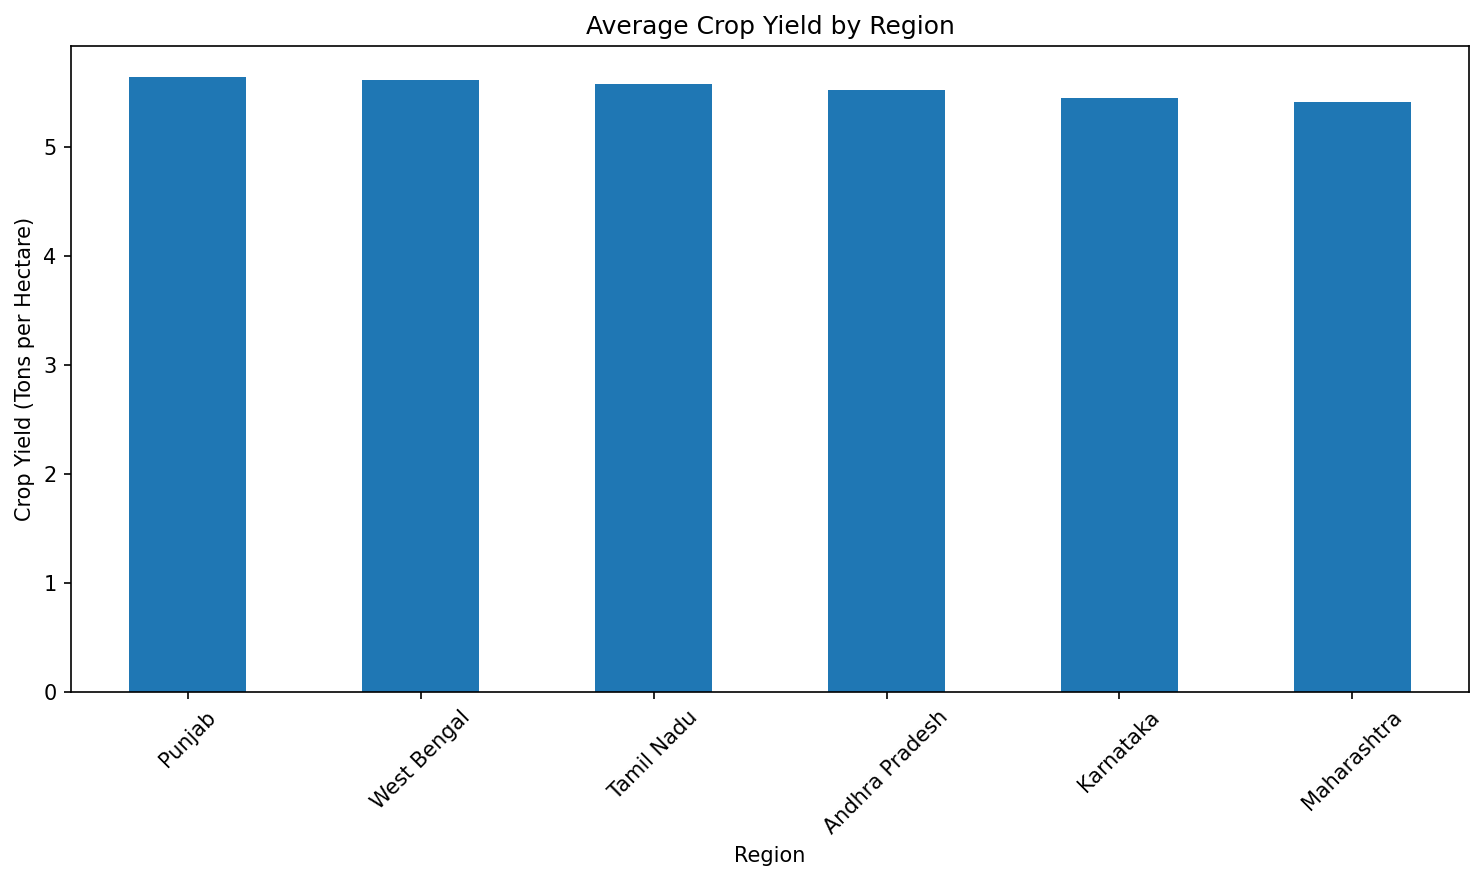

In [64]:
from IPython.display import Image, display

display(
    Image(
        filename="/content/yield_by_region.png"
    )
)

Create Visualization Agent

In [65]:
# =========================================================
# VISUALIZATION AGENT
# =========================================================

async def visualization_agent(state: AgroState):

    print("\n📊 VISUALIZATION AGENT")
    print("Creating agricultural charts...")

    chart_types = [
        "yield_by_region",
        "rainfall_vs_yield",
        "soil_moisture_vs_yield"
    ]

    results = []

    async with Client(mcp) as client:

        for chart_type in chart_types:

            result = await client.call_tool(
                "create_agricultural_chart",
                {
                    "chart_type": chart_type
                }
            )

            output = result.content[0].text

            results.append(
                f"{chart_type}: {output}"
            )

    chart_result = "\n".join(results)

    print("✅ Agricultural charts created")

    return {
        "chart_result": chart_result
    }

Test Visualization Agent

In [66]:
# =========================================================
# TEST VISUALIZATION AGENT
# =========================================================

visual_result = await visualization_agent(
    {
        "user_question":
            "Why is crop yield lower in some regions?"
    }
)

print("\n")
print("=" * 70)
print("📊 VISUALIZATION RESULTS")
print("=" * 70)

print(
    visual_result["chart_result"]
)


📊 VISUALIZATION AGENT
Creating agricultural charts...
✅ Agricultural charts created


📊 VISUALIZATION RESULTS
yield_by_region: SUCCESS: Chart created at /content/yield_by_region.png
rainfall_vs_yield: SUCCESS: Chart created at /content/rainfall_vs_yield.png
soil_moisture_vs_yield: SUCCESS: Chart created at /content/soil_moisture_vs_yield.png


Display all charts


 yield_by_region


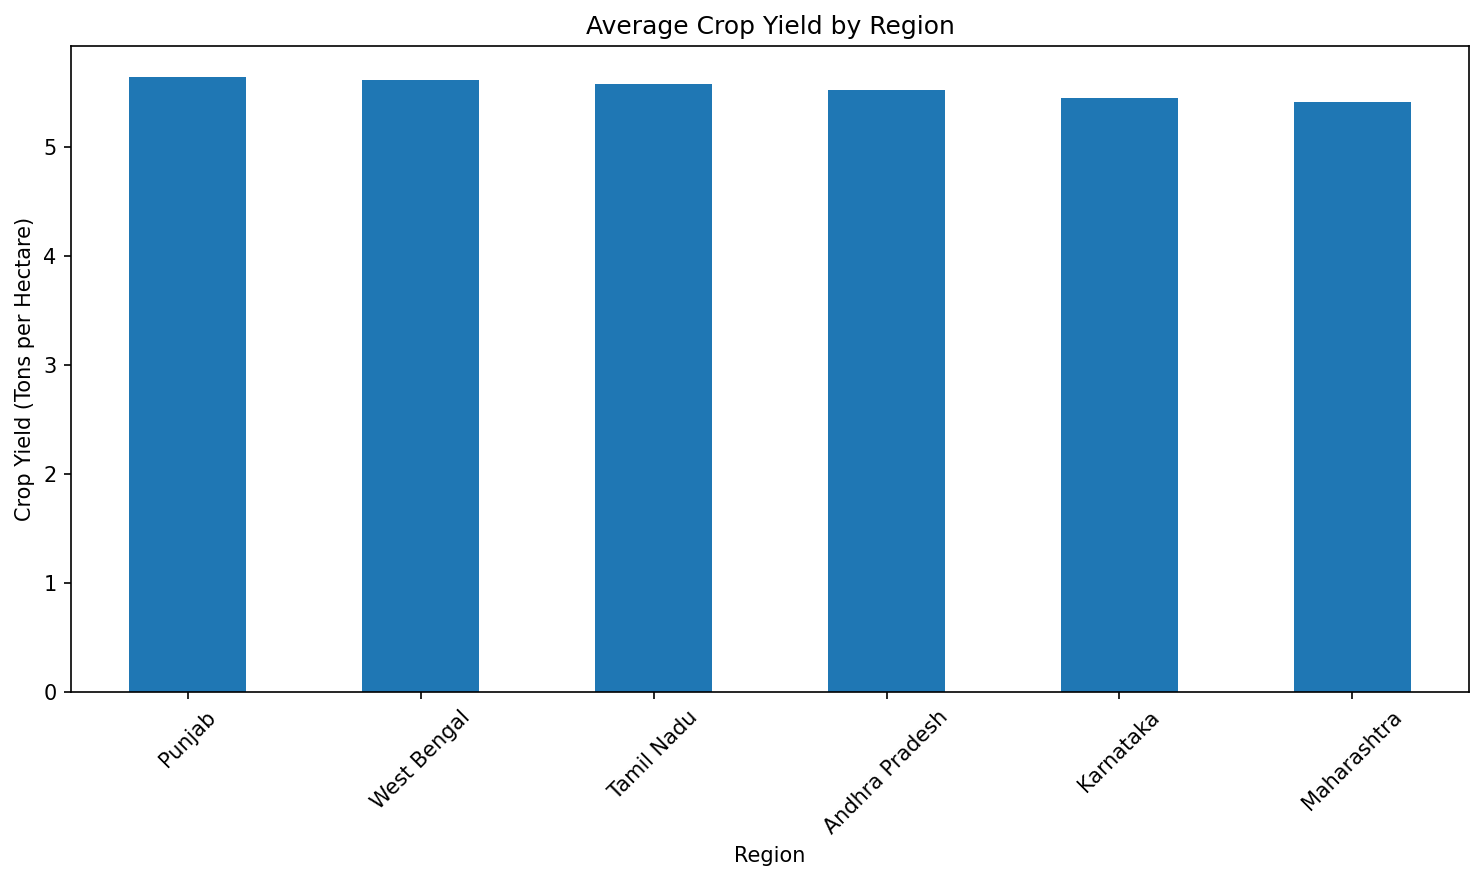


 rainfall_vs_yield


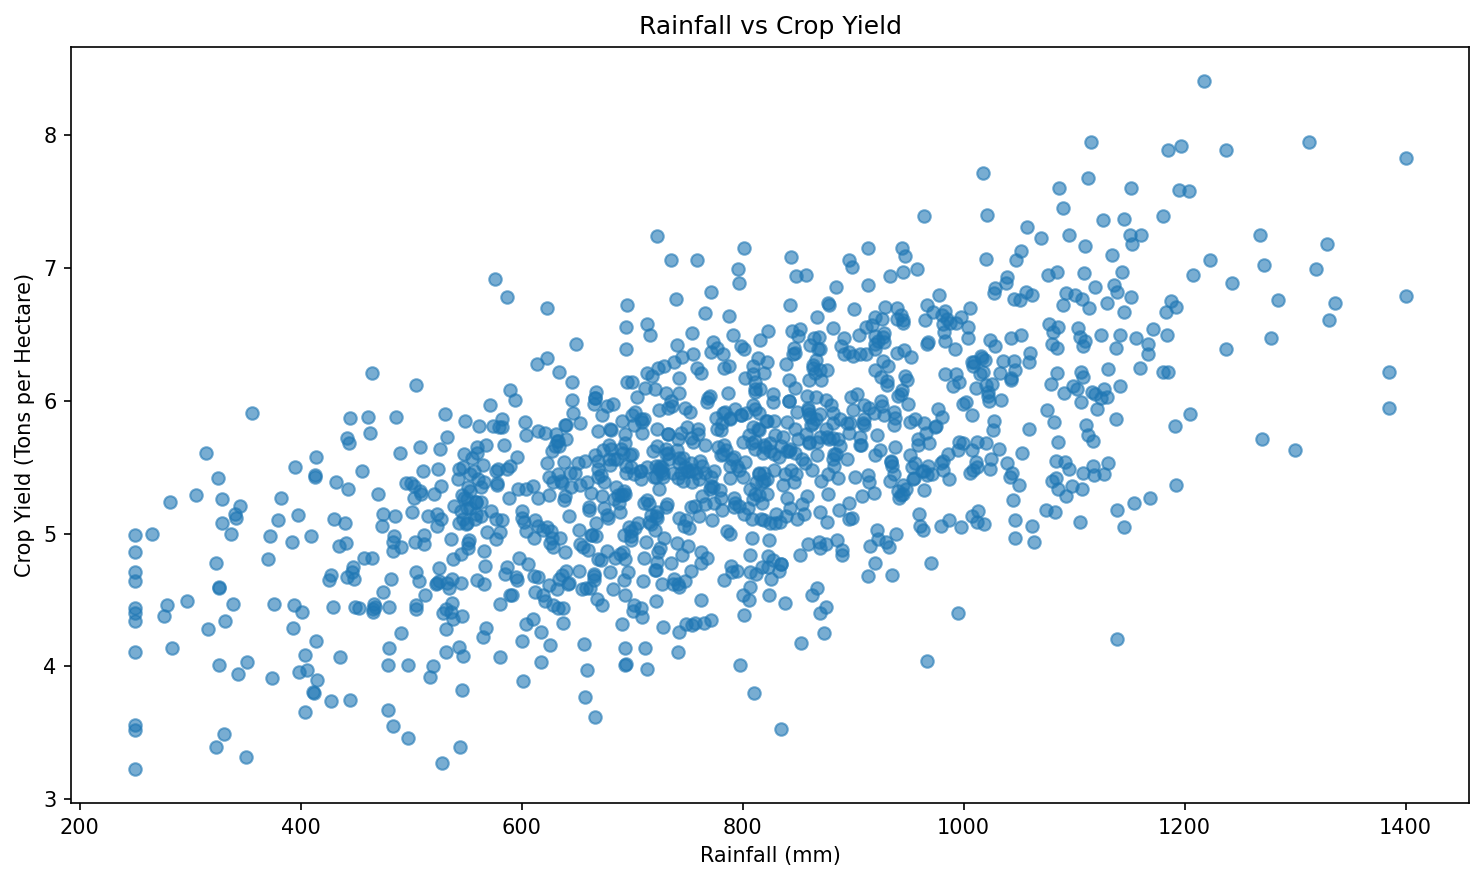


 soil_moisture_vs_yield


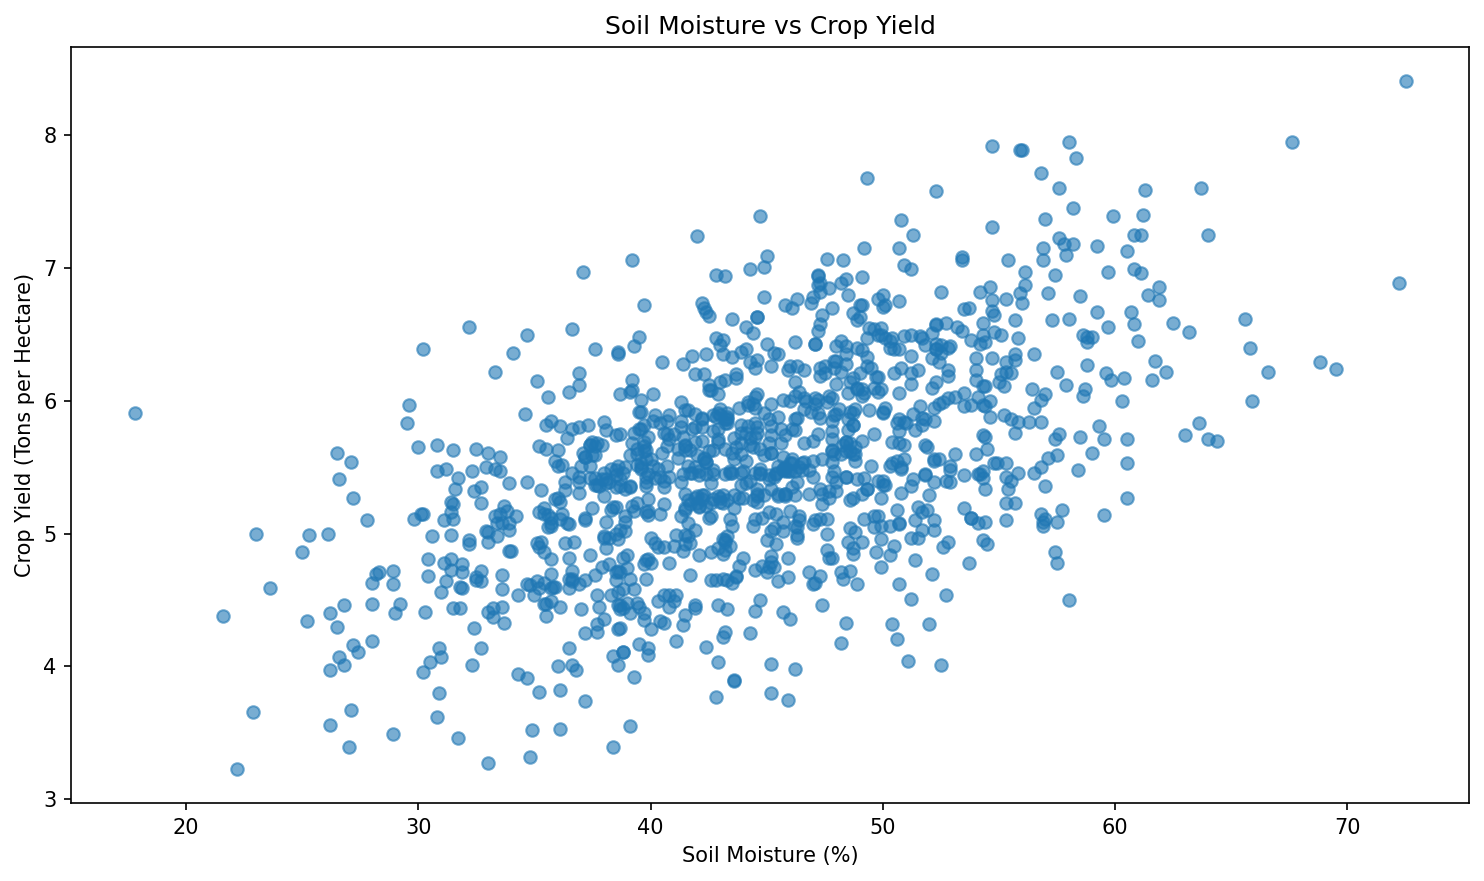

In [67]:
# =========================================================
# DISPLAY AGRICULTURAL CHARTS
# =========================================================

from IPython.display import Image, display

chart_files = [
    "/content/yield_by_region.png",
    "/content/rainfall_vs_yield.png",
    "/content/soil_moisture_vs_yield.png"
]

for chart_file in chart_files:

    # Create the chart if it doesn't exist
    chart_name = chart_file.split("/")[-1].replace(".png", "")

    if not os.path.exists(chart_file):

        async with Client(mcp) as client:

            await client.call_tool(
                "create_agricultural_chart",
                {
                    "chart_type": chart_name
                }
            )

    print("\n", chart_name)

    display(
        Image(
            filename=chart_file
        )
    )

        Add Visualization to LangGraph

        Root Cause
          ↓
        Visualization
          ↓
        Report

In [68]:
# =========================================================
# AGRODETECT — PART 9 LANGGRAPH
# =========================================================

graph_builder = StateGraph(AgroState)


# ---------------------------------------------------------
# NODES
# ---------------------------------------------------------

graph_builder.add_node(
    "planner",
    planner_agent
)

graph_builder.add_node(
    "data_analyst",
    data_analyst_agent
)

graph_builder.add_node(
    "coding_agent",
    coding_agent
)

graph_builder.add_node(
    "execute_code",
    code_execution_node
)

graph_builder.add_node(
    "debugging_agent",
    debugging_agent
)

graph_builder.add_node(
    "root_cause",
    root_cause_agent
)

graph_builder.add_node(
    "visualization",
    visualization_agent
)

graph_builder.add_node(
    "report_agent",
    report_agent
)


# ---------------------------------------------------------
# MAIN FLOW
# ---------------------------------------------------------

graph_builder.add_edge(
    START,
    "planner"
)

graph_builder.add_edge(
    "planner",
    "data_analyst"
)

graph_builder.add_edge(
    "data_analyst",
    "coding_agent"
)

graph_builder.add_edge(
    "coding_agent",
    "execute_code"
)


# ---------------------------------------------------------
# ERROR / SUCCESS ROUTING
# ---------------------------------------------------------

graph_builder.add_conditional_edges(

    "execute_code",

    debug_router,

    {
        "success": "root_cause",
        "debug": "debugging_agent",
        "stop": END
    }
)


# ---------------------------------------------------------
# DEBUG → EXECUTE
# ---------------------------------------------------------

graph_builder.add_edge(
    "debugging_agent",
    "execute_code"
)


# ---------------------------------------------------------
# ROOT CAUSE → VISUALIZATION
# ---------------------------------------------------------

graph_builder.add_edge(
    "root_cause",
    "visualization"
)


# ---------------------------------------------------------
# VISUALIZATION → REPORT
# ---------------------------------------------------------

graph_builder.add_edge(
    "visualization",
    "report_agent"
)


# ---------------------------------------------------------
# REPORT → END
# ---------------------------------------------------------

graph_builder.add_edge(
    "report_agent",
    END
)


agro_graph = graph_builder.compile()

print("✅ AgroDetect Part 9 graph created")

✅ AgroDetect Part 9 graph created


Run the complete workflow

In [69]:
# =========================================================
# RUN AGRODETECT AI — PART 9
# =========================================================

final_state = await agro_graph.ainvoke({

    "user_question":
        "Why is crop yield lower in some regions?",

    "retry_count": 0,

    "max_retries": 3
})


print("\n")
print("=" * 80)
print("🌾 AGRODETECT AI — FINAL REPORT")
print("=" * 80)

print(
    final_state.get(
        "final_report",
        "Report not generated."
    )
)


print("\n")
print("=" * 80)
print("📊 CHARTS")
print("=" * 80)

print(
    final_state.get(
        "chart_result",
        "Charts not generated."
    )
)


🧠 PLANNER AGENT
Creating agricultural investigation plan...
✅ Investigation plan created

🔍 DATA ANALYST AGENT
Getting agricultural data from MCP...
✅ MCP data received
✅ Groq analysis completed

👨‍💻 CODING AGENT
Generating agricultural analysis code...
✅ Python analysis code generated

⚙️ MCP CODE EXECUTION
✅ Code executed successfully

🔎 ROOT-CAUSE ANALYSIS AGENT
Investigating potential agricultural factors...
✅ Root-cause analysis completed

📊 VISUALIZATION AGENT
Creating agricultural charts...
✅ Agricultural charts created

📝 REPORT AGENT
Preparing final agricultural intelligence report...
✅ Final report generated


🌾 AGRODETECT AI — FINAL REPORT
# 🌾 AgroDetect AI Report

## 1. Question
The user's question is: Why is crop yield lower in some regions?

## 2. Key Findings
The key findings of the analysis are:
- Rainfall, soil moisture, fertilizer usage, and irrigation hours are positively correlated with crop yield.
- Loamy soil and the West Bengal region have the highest average cr

                         USER
                          ↓
                   🧠 PLANNER
                          ↓
                  🔍 DATA ANALYST
                          ↓
                   👨‍💻 CODING AGENT
                          ↓
                    MCP EXECUTION
                          ↓
                       ERROR?
                     ↙       ↘
                   YES        NO
                    ↓          ↓
              🛠️ DEBUGGER     🔎 ROOT CAUSE
                    ↓          ↓
                 RETRY     📊 VISUALIZATION
                               ↓
                          📝 REPORT
                               ↓
                              END

| Agent                  | Responsibility                       |
| ---------------------- | ------------------------------------ |
| 🧠 Planner             | Creates investigation plan           |
| 🔍 Data Analyst        | Understands data                     |
| 👨‍💻 Coding Agent     | Generates Python                     |
| 🛠️ Debugging Agent    | Fixes failed code                    |
| 🔎 Root-Cause Agent    | Finds potential contributing factors |
| 📊 Visualization Agent | Creates charts                       |
| 📝 Report Agent        | Creates final report                 |


In [70]:
!pip install -q -U gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.7/30.7 MB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 2.3 MB/s eta 0:00:00


In [71]:
# =========================================================
# AGRODETECT AI — GENERAL AGRICULTURAL CHATBOT
# =========================================================

async def agrodetect_chatbot(message, history):

    if not message or not message.strip():
        return "Please enter an agricultural question."

    print("\n" + "=" * 80)
    print("🌾 AGRODETECT AI")
    print("=" * 80)

    print("USER QUESTION:")
    print(message)

    try:

        # -------------------------------------------------
        # Run complete autonomous LangGraph workflow
        # -------------------------------------------------

        final_state = await agro_graph.ainvoke({

            "user_question": message.strip(),

            "retry_count": 0,

            "max_retries": 3
        })

        # -------------------------------------------------
        # Get final answer
        # -------------------------------------------------

        answer = final_state.get(
            "final_report",
            ""
        )

        if not answer:

            answer = final_state.get(
                "root_cause_analysis",
                ""
            )

        if not answer:

            answer = final_state.get(
                "analysis",
                ""
            )

        if not answer:

            answer = (
                "I could not generate an answer "
                "from the agricultural dataset."
            )

        print("\n✅ ANSWER GENERATED")

        return answer

    except Exception as e:

        print("\n❌ ERROR")
        print(str(e))

        return f"""
### ⚠️ AgroDetect AI Error

I could not complete the analysis.

**Error:** `{str(e)}`
"""

Create the Gradio UI

In [75]:
# =========================================================
# AGRODETECT AI — COMPATIBLE GRADIO UI
# =========================================================

import gradio as gr


demo = gr.ChatInterface(
    fn=agrodetect_chatbot,

    title="🌾 AgroDetect AI",

    description="""
Autonomous Agricultural Data Intelligence

Ask questions about crops, regions, soil, rainfall,
fertilizer, irrigation, temperature, pests, crop yield,
comparisons, statistics, and relationships.

Powered by Groq + LangChain + LangGraph + MCP
""",

    examples=[
        "How much crop yield is there in Tamil Nadu?",
        "Which region has the highest average crop yield?",
        "Which region has the lowest average crop yield?",
        "Which crop has the highest average yield?",
        "Which soil type has the highest crop yield?",
        "What is the average rainfall?",
        "How does rainfall relate to crop yield?",
        "How does soil moisture relate to crop yield?",
        "Does fertilizer usage relate to crop yield?",
        "Which irrigation type has the highest average yield?",
        "What are the minimum and maximum crop yields?",
        "Which region has the highest rainfall?",
        "Which crop is grown most frequently?",
        "Are there missing values in the dataset?",
        "Why is crop yield lower in some regions?",
        "Compare Tamil Nadu and Punjab crop yields.",
        "Give me the top 5 highest-yield regions.",
        "Give me the top 5 crops by average yield.",
        "What are the important factors associated with crop yield?"
    ],

    textbox=gr.Textbox(
        placeholder="Ask any question about the agricultural dataset..."
    )
)

print("✅ AgroDetect Gradio UI created")

✅ AgroDetect Gradio UI created


In [76]:
# =========================================================
# LAUNCH AGRODETECT AI
# =========================================================

demo.launch(
    share=True,
    debug=True
)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://a2ee5ef06b04220ff7.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)



🌾 AGRODETECT AI
USER QUESTION:
What is the average rainfall?

🧠 PLANNER AGENT
Creating agricultural investigation plan...
✅ Investigation plan created

🔍 DATA ANALYST AGENT
Getting agricultural data from MCP...
✅ MCP data received
✅ Groq analysis completed

👨‍💻 CODING AGENT
Generating agricultural analysis code...
✅ Python analysis code generated

⚙️ MCP CODE EXECUTION
The average rainfall is:  780.8185402684563
✅ Code executed successfully

🔎 ROOT-CAUSE ANALYSIS AGENT
Investigating potential agricultural factors...
✅ Root-cause analysis completed

📊 VISUALIZATION AGENT
Creating agricultural charts...
✅ Agricultural charts created

📝 REPORT AGENT
Preparing final agricultural intelligence report...
✅ Final report generated

✅ ANSWER GENERATED

🌾 AGRODETECT AI
USER QUESTION:
Tamilnadu yield details show me

🧠 PLANNER AGENT
Creating agricultural investigation plan...
✅ Investigation plan created

🔍 DATA ANALYST AGENT
Getting agricultural data from MCP...
✅ MCP data received
✅ Groq analys